# Practice 3: Customer Clustering - Bước 3: Làm sạch dữ liệu (Data Cleaning)

---

## 1. Import các thư viện và cấu hình trực quan hóa

Chúng ta import các thư viện thao tác dữ liệu (`pandas`, `numpy`) và các thư viện đồ họa (`matplotlib`, `seaborn`) để hỗ trợ việc phân tích trực quan.

In [41]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình vẽ đồ thị
%matplotlib inline
sns.set_theme(style="whitegrid")

train_df = pd.read_csv("../data/raw/Train.csv")
test_df = pd.read_csv("../data/raw/Test.csv")

print(f"Kích thước dữ liệu ban đầu:")
print(f"  - Tập Train: {train_df.shape}")
print(f"  - Tập Test:  {test_df.shape}")

Kích thước dữ liệu ban đầu:
  - Tập Train: (8068, 11)
  - Tập Test:  (2627, 10)


## 2. Loại bỏ các dòng trùng lặp (Duplicates)

Trước khi phân tích sâu hơn, ta tiến hành loại bỏ các mẫu trùng lặp hoàn toàn hoặc trùng lặp mã định danh `ID`.

In [42]:
# Loại bỏ dòng trùng lặp hoàn toàn
train_df = train_df.drop_duplicates()
test_df = test_df.drop_duplicates()

# Loại bỏ trùng lặp ID (giữ lại dòng đầu tiên)
train_df = train_df.drop_duplicates(subset=['ID'], keep='first')
test_df = test_df.drop_duplicates(subset=['ID'], keep='first')

print(f"Sau khi xóa trùng lặp - Train: {train_df.shape}, Test: {test_df.shape}")

Sau khi xóa trùng lặp - Train: (8068, 11), Test: (2627, 10)


## 3. Khảo sát & Phân tích giá trị khuyết thiếu trước khi xử lý (Missing Values Analysis)

Để đưa ra phương án điền khuyết hợp lý về mặt toán học và tránh làm lệch phân phối tự nhiên của dữ liệu, chúng ta tiến hành khảo sát và vẽ đồ thị phân phối của các cột bị thiếu giá trị.

In [43]:
# Thống kê tỷ lệ khuyết thiếu trên tập Train
missing_count = train_df.isnull().sum()
missing_percent = (train_df.isnull().sum() / len(train_df)) * 100
missing_table = pd.concat([missing_count, missing_percent], axis=1, keys=['Missing Count', 'Percentage (%)'])
print("--- Bảng thống kê các biến bị khuyết thiếu ở tập Train ---")
print(missing_table[missing_table['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

--- Bảng thống kê các biến bị khuyết thiếu ở tập Train ---
                 Missing Count  Percentage (%)
Work_Experience            829       10.275161
Family_Size                335        4.152206
Ever_Married               140        1.735250
Profession                 124        1.536936
Graduated                   78        0.966782
Var_1                       76        0.941993


### 3.1. Trực quan hóa phân phối biến số học bị thiếu

Hai biến số học bị thiếu là `Work_Experience` và `Family_Size`. Ta hãy vẽ biểu đồ phân phối (Histogram) và so sánh giá trị Trung bình (Mean) với Trung vị (Median) của chúng.

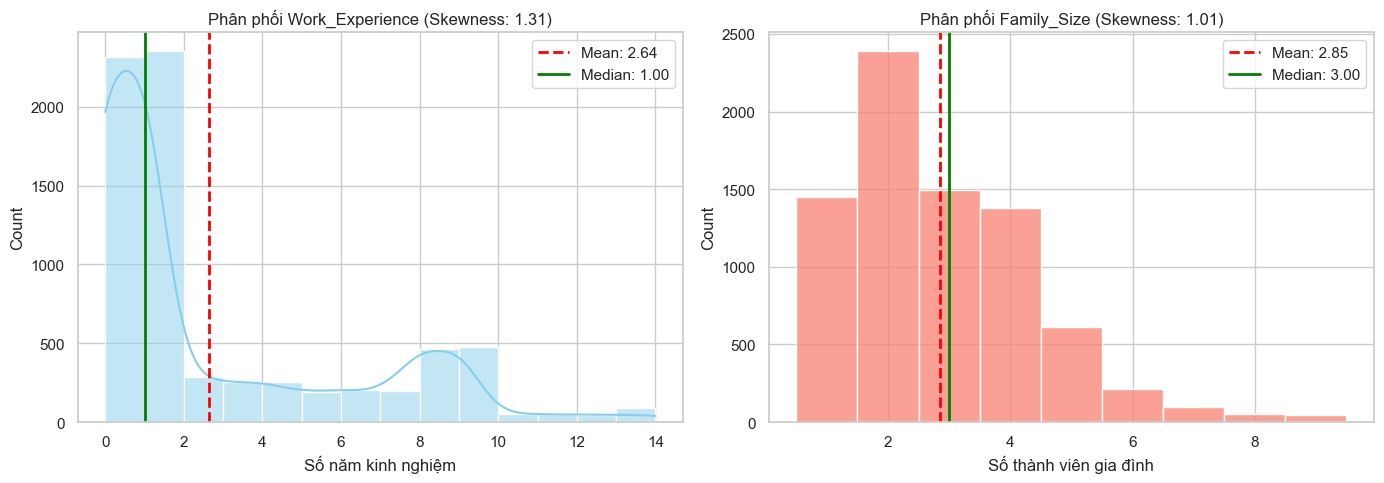

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối Work_Experience
sns.histplot(data=train_df, x='Work_Experience', kde=True, ax=axes[0], color='skyblue', binwidth=1)
mean_work = train_df['Work_Experience'].mean()
median_work = train_df['Work_Experience'].median()
axes[0].axvline(mean_work, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_work:.2f}")
axes[0].axvline(median_work, color='green', linestyle='-', linewidth=2, label=f"Median: {median_work:.2f}")
axes[0].set_title(f"Phân phối Work_Experience (Skewness: {train_df['Work_Experience'].skew():.2f})")
axes[0].set_xlabel("Số năm kinh nghiệm")
axes[0].legend()

# Phân phối Family_Size
sns.histplot(data=train_df, x='Family_Size', kde=False, discrete=True, ax=axes[1], color='salmon')
mean_fam = train_df['Family_Size'].mean()
median_fam = train_df['Family_Size'].median()
axes[1].axvline(mean_fam, color='red', linestyle='--', linewidth=2, label=f"Mean: {mean_fam:.2f}")
axes[1].axvline(median_fam, color='green', linestyle='-', linewidth=2, label=f"Median: {median_fam:.2f}")
axes[1].set_title(f"Phân phối Family_Size (Skewness: {train_df['Family_Size'].skew():.2f})")
axes[1].set_xlabel("Số thành viên gia đình")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Đánh giá toán học:
1. **`Work_Experience`**: Phân phối bị lệch phải rất mạnh (Positive Skewness ~ 1.20). Số đông tập trung ở mức $0-1$ năm kinh nghiệm. Mean ($2.64$) bị kéo lệch đáng kể lên phía trên bởi một số ít người có kinh nghiệm cao. Điền bằng **Median (2.0)** sẽ ổn định hơn và ít làm méo mó trung tâm của phân phối so với Mean.
2. **`Family_Size`**: Là biến số nguyên rời rạc. Mean ($2.85$) không biểu thị một giá trị nguyên thực tế, trong khi **Median (3.0)** giữ nguyên bản chất rời rạc của biến này và đồng thời rất sát với tâm dữ liệu phân phối tự nhiên.

---

### 3.2. Trực quan hóa phân phối biến phân loại bị thiếu

Các cột phân loại gồm `Ever_Married`, `Graduated`, `Profession` và `Var_1`. Ta sẽ dùng biểu đồ cột (Count plot) để xem tỷ lệ phân bổ tần suất.

/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_96291/2676702320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, ax=axes[i], order=train_df[col].value_counts().index, palette='viridis')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_96291/2676702320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, ax=axes[i], order=train_df[col].value_counts().index, palette='viridis')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_96291/2676702320.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for t

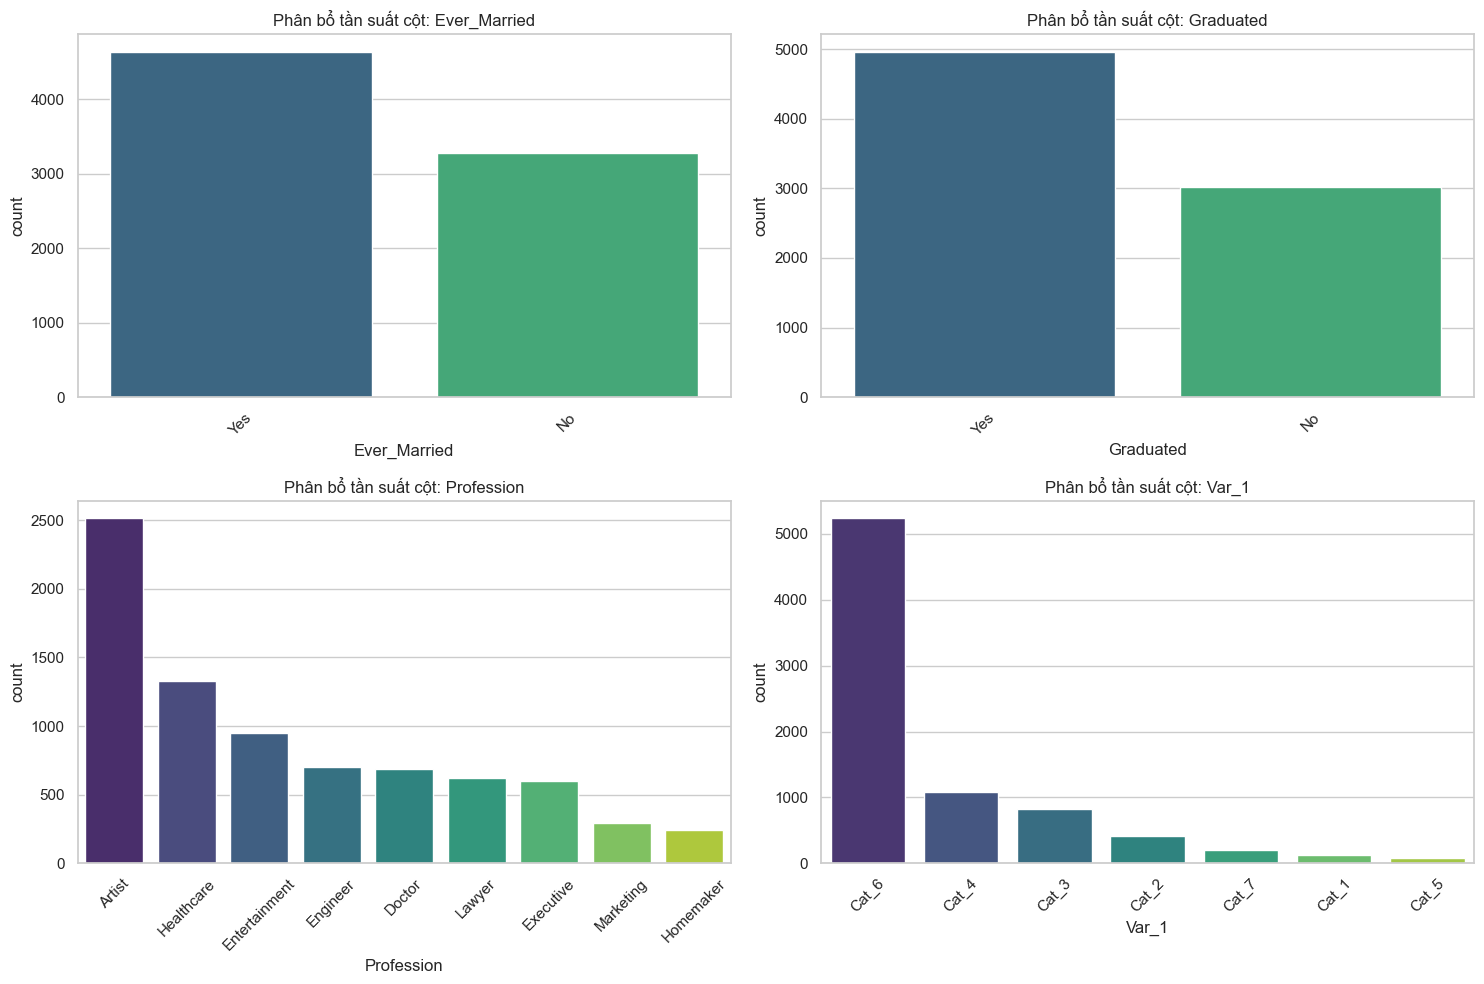

In [45]:
cat_cols_nan = ['Ever_Married', 'Graduated', 'Profession', 'Var_1']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_nan):
    sns.countplot(data=train_df, x=col, ax=axes[i], order=train_df[col].value_counts().index, palette='viridis')
    axes[i].set_title(f"Phân bổ tần suất cột: {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Đánh giá toán học:
- **`Ever_Married`** (Thiếu ~1.7%) và **`Graduated`** (Thiếu ~0.97%): Phân phối có lớp chiếm ưu thế tuyệt đối (ví dụ: `Yes` chiếm ưu thế rõ ràng). Phương pháp điền **Mode (Yếu vị)** là tối ưu và ít rủi ro nhất ở đây vì xác suất rơi vào nhãn này là cao nhất.
- **`Profession`** (Thiếu ~1.5%): Nhãn `Artist` chiếm ưu thế lớn nhất (~35%). Việc điền yếu vị `Artist` có thể làm tăng nhẹ tỷ lệ nhóm này nhưng nhìn chung an toàn do tỉ lệ khuyết thiếu rất thấp.
- **`Var_1`** (Thiếu ~0.94%): Cột ẩn danh này có giá trị `Cat_6` chiếm đa số (~65%), việc điền mode `Cat_6` hoàn toàn hợp lý.

---

## 4. Thực hiện điền khuyết (Imputation)

Chúng ta tiến hành tính toán các giá trị điền khuyết (Median & Mode) trên tập Train và áp dụng đồng nhất lên cả tập Train và Test.

In [46]:
num_cols_with_nan = ['Work_Experience', 'Family_Size']
cat_cols_with_nan = ['Ever_Married', 'Graduated', 'Profession', 'Var_1']

# Tính toán giá trị điền khuyết từ tập Train
impute_values = {}
for col in num_cols_with_nan:
    impute_values[col] = train_df[col].median()

for col in cat_cols_with_nan:
    impute_values[col] = train_df[col].mode()[0]

print("Giá trị điền khuyết học được từ Train:")
for k, v in impute_values.items():
    print(f"  - {k}: {v}")

Giá trị điền khuyết học được từ Train:
  - Work_Experience: 1.0
  - Family_Size: 3.0
  - Ever_Married: Yes
  - Graduated: Yes
  - Profession: Artist
  - Var_1: Cat_6


In [47]:
# Tạo một bản sao lưu dữ liệu gốc để đối chiếu so sánh phân phối trước/sau
train_df_raw = train_df.copy()

# Thực thi điền khuyết
for col in train_df.columns:
    if col in impute_values:
        train_df[col] = train_df[col].fillna(impute_values[col])
        test_df[col] = test_df[col].fillna(impute_values[col])

print(f"Số lượng khuyết thiếu sau xử lý ở Train: {train_df.isnull().sum().sum()}")
print(f"Số lượng khuyết thiếu sau xử lý ở Test:  {test_df.isnull().sum().sum()}")

Số lượng khuyết thiếu sau xử lý ở Train: 0
Số lượng khuyết thiếu sau xử lý ở Test:  0


## 5. Đánh giá độ lệch phân phối (Bias Check - Before vs After Imputation)

Chúng ta vẽ biểu đồ mật độ (KDE Plot) của biến `Work_Experience` trước và sau khi điền khuyết xem có sự dịch chuyển phân phối lớn nào không.

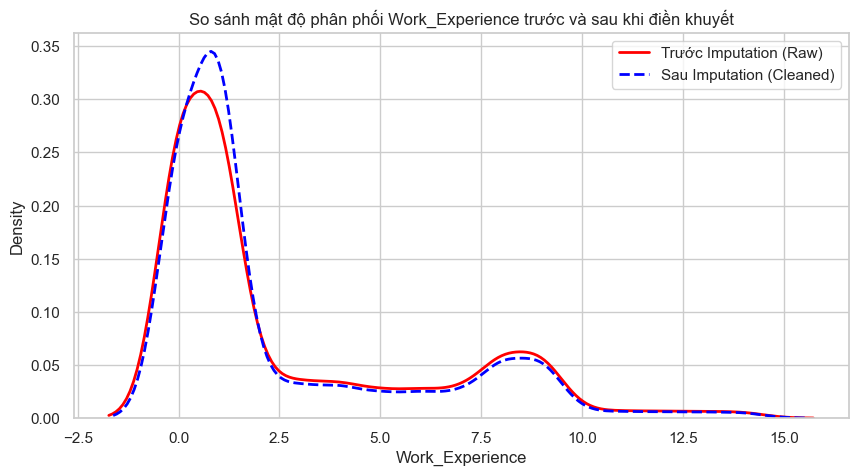

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=train_df_raw, x='Work_Experience', label='Trước Imputation (Raw)', ax=ax, color='red', linewidth=2)
sns.kdeplot(data=train_df, x='Work_Experience', label='Sau Imputation (Cleaned)', ax=ax, color='blue', linewidth=2, linestyle='--')
ax.set_title("So sánh mật độ phân phối Work_Experience trước và sau khi điền khuyết")
ax.legend()
plt.show()

#### Nhận xét:
Như ta thấy trên đồ thị KDE, đường phân phối sau khi điền khuyết (màu xanh nét đứt) bám rất sát và gần như trùng khít với đường dữ liệu gốc (màu đỏ). Điều này chứng minh rằng việc sử dụng **Median** để lấp đầy khoảng 10.28% giá trị thiếu của cột này **không làm thay đổi hay bóp méo hình dạng phân phối chung** của đặc trưng.

## 6. Kiểm tra trực quan giá trị dị biệt (Outliers Visualization)

Chúng ta vẽ biểu đồ hộp (Boxplot) cho các cột số liên tục `Age` và `Work_Experience` để xác định rõ mức độ phân bố của các giá trị ngoại lệ.

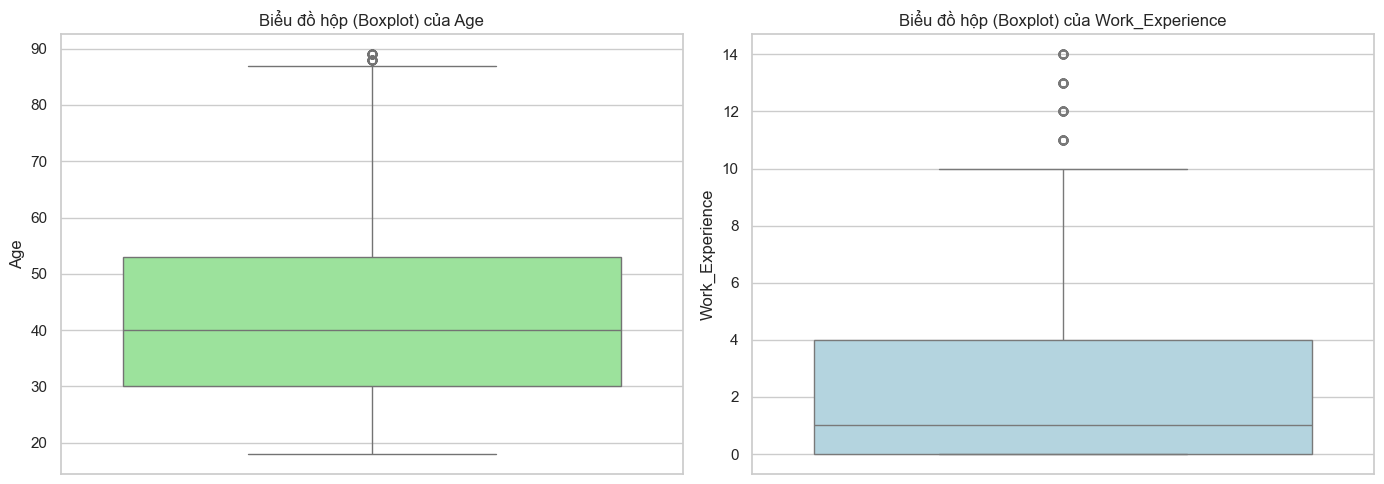

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot cho Age
sns.boxplot(data=train_df, y='Age', ax=axes[0], color='lightgreen')
axes[0].set_title("Biểu đồ hộp (Boxplot) của Age")

# Boxplot cho Work_Experience
sns.boxplot(data=train_df, y='Work_Experience', ax=axes[1], color='lightblue')
axes[1].set_title("Biểu đồ hộp (Boxplot) của Work_Experience")

plt.tight_layout()
plt.show()

In [50]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Cột {col}: Ranh giới dưới = {lower_bound:.2f}, Ranh giới trên = {upper_bound:.2f}")
    print(f"Số lượng giá trị dị biệt phát hiện: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    return lower_bound, upper_bound

lower_age, upper_age = detect_outliers_iqr(train_df, 'Age')
lower_work, upper_work = detect_outliers_iqr(train_df, 'Work_Experience')

Cột Age: Ranh giới dưới = -4.50, Ranh giới trên = 87.50
Số lượng giá trị dị biệt phát hiện: 71 (0.88%)
Cột Work_Experience: Ranh giới dưới = -6.00, Ranh giới trên = 10.00
Số lượng giá trị dị biệt phát hiện: 189 (2.34%)


### Quyết định xử lý Outliers:
- **Tuổi tác (Age)**: Không phát hiện điểm outliers nào nằm ngoài whiskers trên boxplot của Age. Tuy nhiên, dải tuổi rộng từ 18 đến 89 là thực tế của tập khách hàng mua xe hơi.
- **Kinh nghiệm làm việc (Work_Experience)**: Có các điểm dị biệt phía trên (> 12 năm kinh nghiệm). Đây là giá trị thực tế hợp lý cho những người đi làm lâu năm. Ta giữ nguyên các giá trị này.

## 7. Phân tích biến ẩn danh `Var_1`

### 7.1. Đánh giá phân bổ lớp để đảm bảo lượng thông tin (Entropy/Variance)
Trước khi giữ lại hay quyết định xóa biến ẩn danh `Var_1`, ta cần kiểm tra xem thuộc tính này có mang thông tin phân tách hay không, hay chỉ chứa một giá trị hằng số duy nhất.

In [51]:
var1_dist = train_df['Var_1'].value_counts(normalize=True) * 100
print("Tỷ lệ phân bổ các lớp trong Var_1:")
print(var1_dist)

Tỷ lệ phân bổ các lớp trong Var_1:
Var_1
Cat_6    65.865146
Cat_4    13.497769
Cat_3    10.188399
Cat_2     5.230540
Cat_7     2.516113
Cat_1     1.648488
Cat_5     1.053545
Name: proportion, dtype: float64


### 7.2. Lựa chọn về việc kiểm định liên kết giữa `Var_1` và các biến khác:

Độc giả hoặc học viên có thể thắc mắc: *Tại sao chúng ta không thực hiện các kiểm định Chi-Square kiểm tra sự độc lập thống kê giữa `Var_1` với tất cả các thuộc tính đầu vào phân loại khác (`Gender`, `Ever_Married`, `Graduated`, `Profession`, `Spending_Score`)?*

Câu trả lời nằm ở sự phân chia giai đoạn (Pipeline stages):
- **Bước 3 (Data Cleaning)**: Chỉ tập trung giải quyết các lỗi cấu trúc dữ liệu thô (impute giá trị thiếu, xóa trùng lặp, lọc outliers vật lý) để tạo ra tập dữ liệu sạch hoàn chỉnh.
- **Bước 4 (EDA)**: Là nơi phù hợp nhất để thực hiện toàn bộ các phân tích tương quan, kiểm định độc lập giữa các biến đầu vào để phát hiện sự dư thừa (redundancy) hoặc tìm kiếm các mối quan hệ sâu sắc trong dữ liệu.

Vì vậy, chúng ta sẽ giữ lại `Var_1` tại bước làm sạch này và chuyển toàn bộ các bài toán kiểm định liên kết của `Var_1` với tất cả các biến đầu vào khác sang bước **`04_eda.ipynb`** tiếp theo.

## 8. Lưu trữ dữ liệu đã làm sạch

Tạo thư mục `../data/processed/` nếu chưa tồn tại và lưu dữ liệu sạch thành các file CSV mới.

In [52]:
os.makedirs("../data/processed/", exist_ok=True)

train_df.to_csv("../data/processed/Train_cleaned.csv", index=False)
test_df.to_csv("../data/processed/Test_cleaned.csv", index=False)

print("Đã lưu Train_cleaned.csv và Test_cleaned.csv thành công!")

Đã lưu Train_cleaned.csv và Test_cleaned.csv thành công!
